In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# importing data
shopping_data = pd.read_csv('./dataset/shopping_trends.csv')
shopping_data

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [4]:
# 1. structure check
print(f"Shopping Dataset Shape: {shopping_data.shape}\n")
print(f"Shopping Dataset Columns: {shopping_data.columns}\n")
print(f"Shopping Dataset No. of Dimensions: {shopping_data.ndim}\n")
print(f"Categorical data columns: {shopping_data.select_dtypes(include=['category', 'object', 'bool', 'str']).columns}\n")
shopping_data.info()

Shopping Dataset Shape: (3900, 19)

Shopping Dataset Columns: Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='str')

Shopping Dataset No. of Dimensions: 2

Categorical data columns: Index(['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color',
       'Season', 'Subscription Status', 'Payment Method', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Cust

In [5]:
# 2. checking for missing values
shopping_data.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [6]:
# 3. Duplicates
print("Duplicated Data Says True! \n")
print(f"{shopping_data.duplicated()}\n")
print(f"Total number of duplicated rows: {shopping_data.duplicated().sum()}")

Duplicated Data Says True! 

0       False
1       False
2       False
3       False
4       False
        ...  
3895    False
3896    False
3897    False
3898    False
3899    False
Length: 3900, dtype: bool

Total number of duplicated rows: 0


In [7]:
# 4. Summary statistics
print("Data Statistics : \n")
print(shopping_data.describe(), end="\n\n")
print("Including Objects Only")
print(shopping_data.describe(include='object'))

Data Statistics : 

       Customer ID          Age  Purchase Amount (USD)  Review Rating  \
count  3900.000000  3900.000000            3900.000000    3900.000000   
mean   1950.500000    44.068462              59.764359       3.749949   
std    1125.977353    15.207589              23.685392       0.716223   
min       1.000000    18.000000              20.000000       2.500000   
25%     975.750000    31.000000              39.000000       3.100000   
50%    1950.500000    44.000000              60.000000       3.700000   
75%    2925.250000    57.000000              81.000000       4.400000   
max    3900.000000    70.000000             100.000000       5.000000   

       Previous Purchases  
count         3900.000000  
mean            25.351538  
std             14.447125  
min              1.000000  
25%             13.000000  
50%             25.000000  
75%             38.000000  
max             50.000000  

Including Objects Only
       Gender Item Purchased  Category Locatio

C:\Users\keval\AppData\Local\Temp\ipykernel_6624\2454220465.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(shopping_data.describe(include='object'))


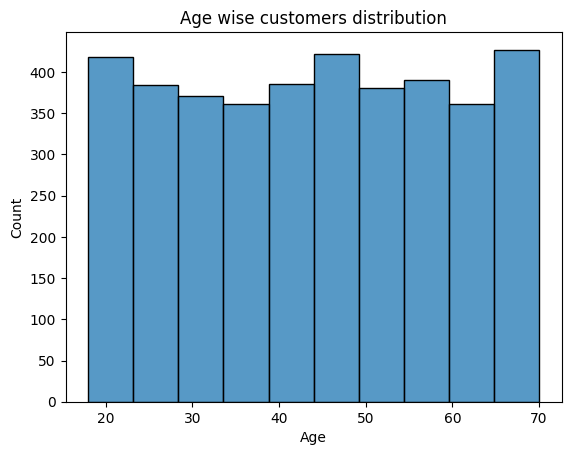

In [ ]:
# 5. Analysis

# 5.1 age wise customers
sns.histplot(data=shopping_data, x="Age", bins=10)
plt.title("Age wise customers distribution")
plt.show()

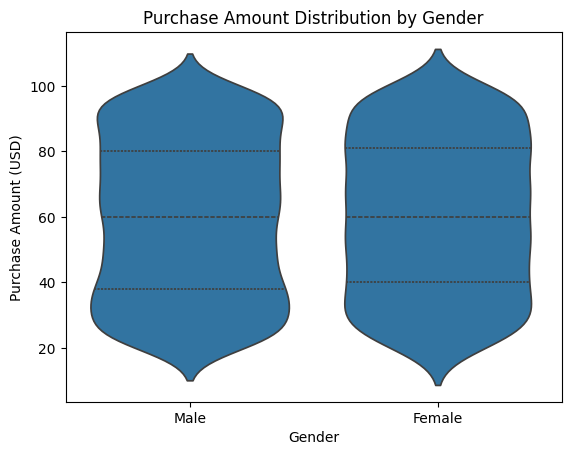

In [ ]:
# 5.2 Sex based purchase distribution

sns.violinplot(
    data=shopping_data, 
    x="Gender", 
    y="Purchase Amount (USD)",
    inner="quartile"
)
plt.title("Purchase Amount Distribution by Gender")
plt.show()

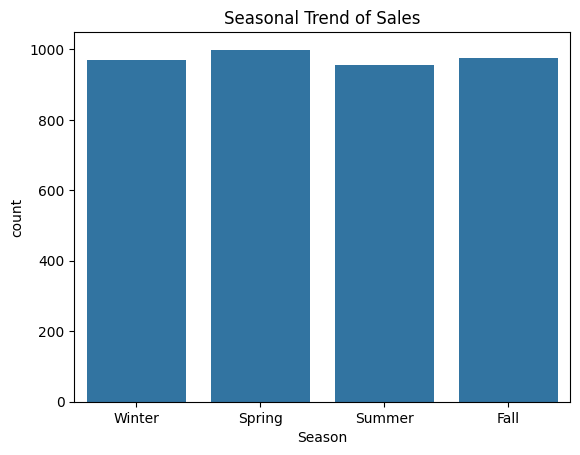

In [55]:
# 5.3 seasonal trend of sales

sns.countplot(data=shopping_data, x="Season")
plt.title("Seasonal Trend of Sales")
# len(shopping_data[shopping_data['Season'] == "Winter"])
plt.show()

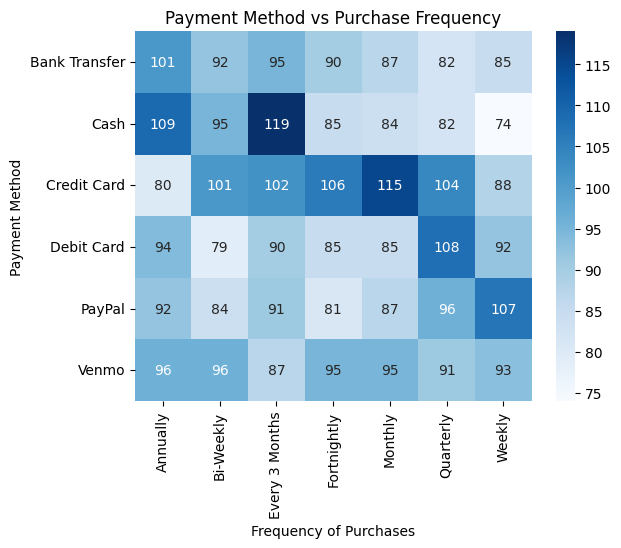

In [ ]:
# 5.4 Payment method and frequency of purchase relation

ct = pd.crosstab(
    shopping_data["Payment Method"],
    shopping_data["Frequency of Purchases"]
)
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Payment Method vs Purchase Frequency")
plt.show()

In [ ]:
# location vs fav product

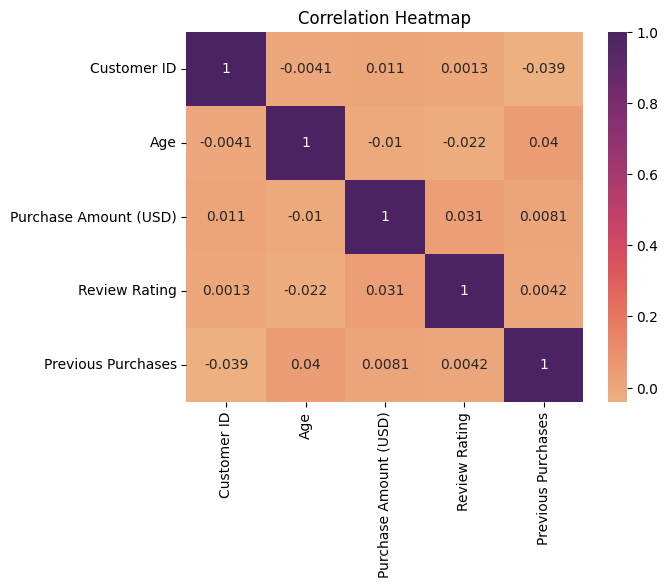

In [12]:
# 6. Correlation check
corr_matrix = shopping_data.select_dtypes(include="number").corr()

sns.heatmap(data=corr_matrix, annot=True, cmap="flare")
plt.title("Correlation Heatmap")
plt.show()

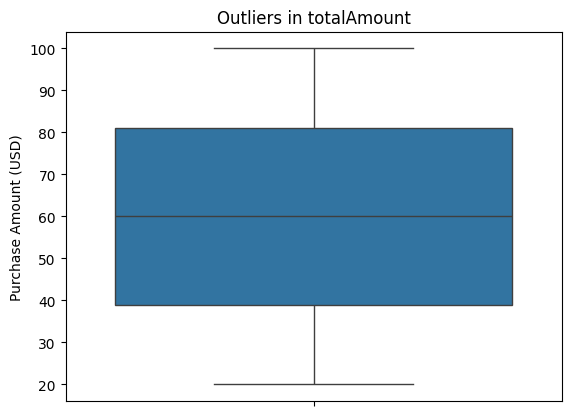

In [ ]:
# 7. Outlier detection'
# no outliers existing
bx = sns.boxplot(data=shopping_data, y="Purchase Amount (USD)")
plt.title("Outliers in totalAmount")
plt.show()

In [28]:
# 8. Skewness check
shopping_data.select_dtypes(include='number').skew()

Customer ID              0.000000
Age                     -0.006380
Purchase Amount (USD)    0.012702
Review Rating            0.004525
Previous Purchases       0.003121
dtype: float64

  Subscription Status  Purchase Amount (USD)
0                  No                 170436
1                 Yes                  62645


<Axes: xlabel='Subscription Status', ylabel='Purchase Amount (USD)'>

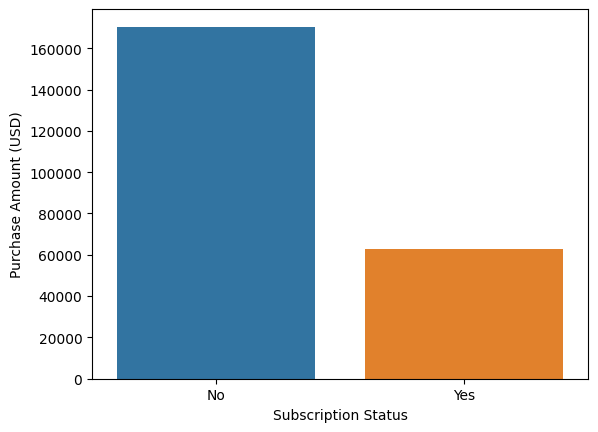

In [ ]:
# 9. Feature insights
# impact of subscription on purchase
subscription_data = shopping_data.groupby('Subscription Status')['Purchase Amount (USD)'].sum().reset_index()
sns.barplot(data=subscription_data, x="Subscription Status", y="Purchase Amount (USD)", hue="Subscription Status")